# Exercise 1 

In this exercise, we will work with the `spam.csv` data file. This file contains text and a label attached to each text. The goal is to explore this data. 

### Exercise 1(a) (2 points)

Load the `pandas` and `numpy` libraries.

In [1]:
import pandas as pd
import numpy as np

### Exercise 1(b) (2 points)

Read the `csv` file and create a data-frame called `spam_df`.

In [2]:
spam_df = pd.read_csv("spam.csv")
spam_df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Exercise 1(c) (2 points)

Report the `shape` of `spam_df`.

In [3]:
spam_df.shape

(5572, 2)

### Exercise 1(d) (2 points)

Report the frequency table of `label`.

In [4]:
spam_df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [6]:
round(100*spam_df["label"].value_counts(normalize=True), 2)

label
ham     86.59
spam    13.41
Name: proportion, dtype: float64

### Exercise 1(e) (2 points)

Using the `string` library, remove all the punctuation of the `text` column.

In [7]:
import string

spam_df["text_clean"] = spam_df["text"].str.replace(f"[{string.punctuation}]", "", regex=True)
spam_df.head()

,label,text,text_clean
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...


### Exercise 1(f) (10 points)

Using the `nltk` library, remove stopwords and pronouns from `text_clean` and store in another column called `'text_clean_1'`. If you don't have `nltk` installed in your computer, run the following code:

```
pip install nltk
```

In [15]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
pronouns = ["i", "me", "my", "mine", "you", "your", "yours", "he", "him", "his", "she", "her", "hers", "we", "us", "our", "ours", "they", "them", "their", "theirs", "2", "u", "ur", "im"]

def clean_text(text):

    # Tokenize the text
    tokens = word_tokenize(text.lower())

    # Remove stopwords and pronouns
    cleaned_tokens = [token for token in tokens if token not in stop_words and token not in pronouns]

    return " ".join(cleaned_tokens)

spam_df["text_clean_1"] = spam_df["text_clean"].apply(clean_text)
spam_df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/oscarm524/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/oscarm524/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,label,text,text_clean,text_clean_1
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts 21s...
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,dun say early hor c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,nah dont think goes usf lives around though


### Exercise 1(g) (3 points)

Split the `spam_df` based on `label` into two data-frames called: `ham` and `spam`.

In [16]:
ham = spam_df[spam_df["label"] == "ham"].reset_index(drop=True)
spam = spam_df[spam_df["label"] == "spam"].reset_index(drop=True)

### Exercise 1(h) (5 points)

Find the top 10 most frequent words in `ham` messages and visualize them using a bar chart.

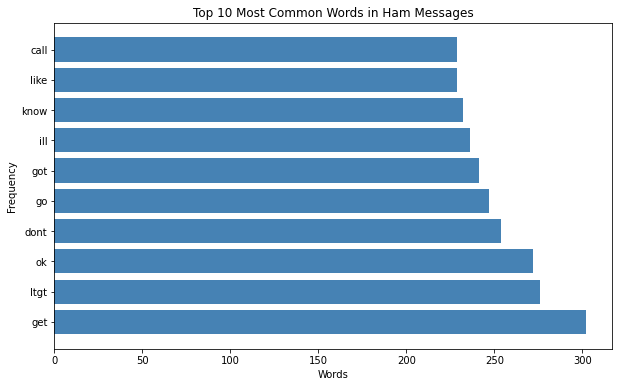

In [17]:
import matplotlib.pyplot as plt
from collections import Counter

ham_text = ham["text_clean_1"]
ham_words = " ".join(ham_text).split()

ham_word_counts = Counter(ham_words)

# Selecting the top 10 words
top_10_ham_words = ham_word_counts.most_common(10)

# Extracting the words and their frequencies
top_10_ham_words_words = [word for word, count in top_10_ham_words]
top_10_ham_words_counts = [count for word, count in top_10_ham_words]

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_10_ham_words_words, top_10_ham_words_counts, color='steelblue')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 10 Most Common Words in Ham Messages')
plt.show()

### Exercise 1(i) (5 points)

Find the top 10 most frequent words in `spam` messages and visualize them using a bar chart.

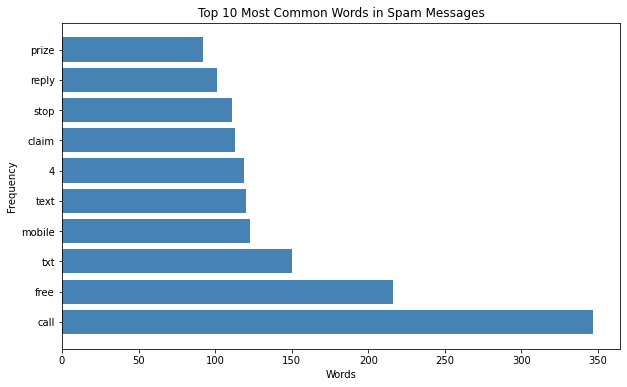

In [18]:
import matplotlib.pyplot as plt
from collections import Counter

spam_text = spam["text_clean_1"]
spam_words = " ".join(spam_text).split()

spam_word_counts = Counter(spam_words)

# Selecting the top 10 words
top_10_spam_words = spam_word_counts.most_common(10)

# Extracting the words and their frequencies
top_10_spam_words_words = [word for word, count in top_10_spam_words]
top_10_spam_words_counts = [count for word, count in top_10_spam_words]

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_10_spam_words_words, top_10_spam_words_counts, color='steelblue')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 10 Most Common Words in Spam Messages')
plt.show()